# Aula 5 — Erro experimental e incerteza em Física usando Python

Nesta aula, vamos trabalhar com uma situação típica de laboratório de Física:

**determinar a aceleração da gravidade \(g\) a partir de medidas de um pêndulo simples.**

A ideia principal não é apenas calcular um valor, mas entender:

- como carregar dados experimentais em CSV;
- como visualizar dados;
- como calcular média e desvio padrão;
- como estimar erro absoluto e erro relativo;
- como trabalhar com incerteza;
- como identificar dispersão experimental;
- como apresentar resultado físico com incerteza.

## Contexto físico

Para pequenas oscilações, o período de um pêndulo simples é dado por:

$$
T = 2\pi \sqrt{\frac{L}{g}}
$$

Elevando ao quadrado:

$$
T^2 = \frac{4\pi^2}{g}L
$$

Assim, se fizermos um gráfico de \(T^2\) em função de \(L\), esperamos uma reta.

O coeficiente angular dessa reta é:

$$
a = \frac{4\pi^2}{g}
$$

Logo:

$$
g = \frac{4\pi^2}{a}
$$

## 1. Montando o Google Drive

Como o arquivo CSV está salvo no Google Drive, primeiro precisamos montar o Drive no Colab.

In [1]:
from google.colab import drive

# Este comando conecta o Google Colab ao seu Google Drive.
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Importando as bibliotecas

Usaremos:

- `pandas` para carregar e organizar os dados;
- `numpy` para cálculos numéricos;
- `matplotlib` para gráficos;
- `scipy.stats` para ajuste linear e análise estatística.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Isso faz com que as figuras fiquem um pouco maiores e mais fáceis de visualizar em sala de aula.
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

## 3. Carregando o arquivo CSV

O arquivo usado nesta aula é:

`dados_fisica_erro_incerteza_pendulo_200_pontos.csv`

Ele deve estar salvo na pasta:

`/content/drive/MyDrive/Colab Notebooks/`

In [4]:
# Caminho para o arquivo CSV no Google Drive..
file_path = '/content/drive/MyDrive/Colab Notebooks/dados_fisica_erro_incerteza_pendulo_200_pontos.csv'

# Lendo o arquivo CSV usando pandas.
df = pd.read_csv(file_path)

# Exibindo as primeiras linhas do conjunto de dados.
df.head()

,medicao,grupo_comprimento,repeticao,comprimento_m,tempo_10_oscilacoes_s,periodo_s,g_estimado_m_s2,incerteza_comprimento_m,incerteza_tempo_s
0,1,1,1,0.2468,10.075,1.0075,9.5984,0.002,0.01
1,2,1,2,0.2488,10.028,1.0028,9.7681,0.002,0.01
2,3,1,3,0.2500,10.098,1.0098,9.6786,0.002,0.01
3,4,1,4,0.2501,10.168,1.0168,9.5498,0.002,0.01
4,5,1,5,0.2491,9.991,0.9991,9.8519,0.002,0.01


## 4. Entendendo as colunas do arquivo

O arquivo contém 200 medições simulando um experimento de pêndulo simples.

As colunas são:

- `medicao`: número da medição;
- `grupo_comprimento`: grupo associado a um mesmo comprimento;
- `repeticao`: repetição da medida para o mesmo comprimento;
- `comprimento_m`: comprimento do pêndulo em metros;
- `tempo_10_oscilacoes_s`: tempo medido para 10 oscilações;
- `periodo_s`: período de uma oscilação;
- `g_estimado_m_s2`: valor estimado de \(g\) para cada medição;
- `incerteza_comprimento_m`: incerteza instrumental do comprimento;
- `incerteza_tempo_s`: incerteza instrumental do cronômetro.

In [5]:
# Informações gerais sobre o conjunto de dados.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   medicao                  200 non-null    int64  
 1   grupo_comprimento        200 non-null    int64  
 2   repeticao                200 non-null    int64  
 3   comprimento_m            200 non-null    float64
 4   tempo_10_oscilacoes_s    200 non-null    float64
 5   periodo_s                200 non-null    float64
 6   g_estimado_m_s2          200 non-null    float64
 7   incerteza_comprimento_m  200 non-null    float64
 8   incerteza_tempo_s        200 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 14.2 KB


In [6]:
# Resumo estatístico das colunas numéricas.
df.describe()

,medicao,grupo_comprimento,repeticao,comprimento_m,tempo_10_oscilacoes_s,periodo_s,g_estimado_m_s2,incerteza_comprimento_m,incerteza_tempo_s
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02
mean,100.500000,10.500000,5.500000,0.724829,16.704405,1.670440,9.812151,2.000000e-03,1.000000e-02
std,57.879185,5.780751,2.879489,0.289041,3.572555,0.357256,0.111759,1.304307e-18,6.956306e-18
min,1.000000,1.000000,1.000000,0.246800,9.991000,0.999100,9.471300,2.000000e-03,1.000000e-02
25%,50.750000,5.750000,3.000000,0.486025,13.985750,1.398575,9.753725,2.000000e-03,1.000000e-02
50%,100.500000,10.500000,5.500000,0.725100,17.050500,1.705050,9.799000,2.000000e-03,1.000000e-02
75%,150.250000,15.250000,8.000000,0.964425,19.738250,1.973825,9.882925,2.000000e-03,1.000000e-02
max,200.000000,20.000000,10.000000,1.202100,22.051000,2.205100,10.156700,2.000000e-03,1.000000e-02


## 5. Visualização inicial dos dados

Vamos começar observando a relação entre o comprimento do pêndulo e o período medido.

Fisicamente, esperamos que quanto maior o comprimento do pêndulo, maior seja o período de oscilação.

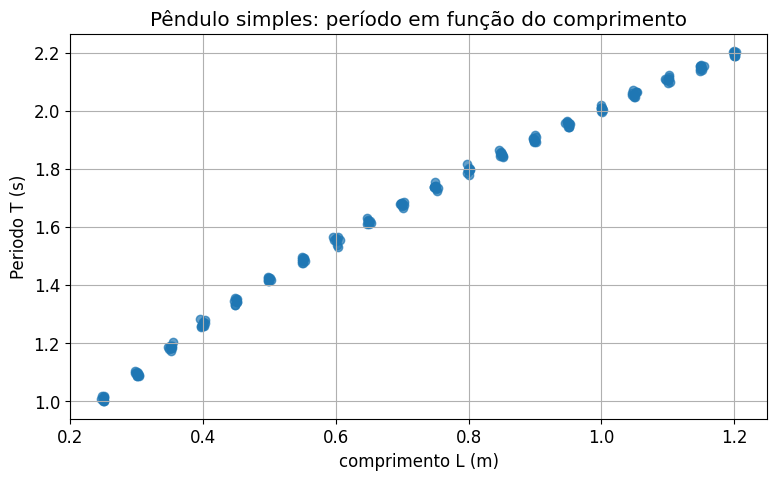

In [7]:
plt.figure()

plt.scatter(df['comprimento_m'], df['periodo_s'], alpha=0.7)

plt.xlabel('comprimento L (m)')
plt.ylabel('Periodo T (s)')
plt.title('Pêndulo simples: período em função do comprimento')
plt.grid(True)

plt.show()

## 6. Criando a coluna \(T^2\)

Como a equação linearizada do pêndulo usa \(T^2\), vamos criar uma nova coluna no DataFrame.

A relação esperada é:

$$
T^2 = \frac{4\pi^2}{g}L
$$

Portanto, o gráfico de \(T^2\) contra \(L\) deve ser aproximadamente linear.

In [8]:
# Criando uma nova coluna com o período ao quadrado..
df['periodo_ao_quadrado_s2'] = df['periodo_s']**2

# Exibindo a tabela atualizada.
df.head()

,medicao,grupo_comprimento,repeticao,comprimento_m,tempo_10_oscilacoes_s,periodo_s,g_estimado_m_s2,incerteza_comprimento_m,incerteza_tempo_s,periodo_ao_quadrado_s2
0,1,1,1,0.2468,10.075,1.0075,9.5984,0.002,0.01,1.015056
1,2,1,2,0.2488,10.028,1.0028,9.7681,0.002,0.01,1.005608
2,3,1,3,0.2500,10.098,1.0098,9.6786,0.002,0.01,1.019696
3,4,1,4,0.2501,10.168,1.0168,9.5498,0.002,0.01,1.033882
4,5,1,5,0.2491,9.991,0.9991,9.8519,0.002,0.01,0.998201


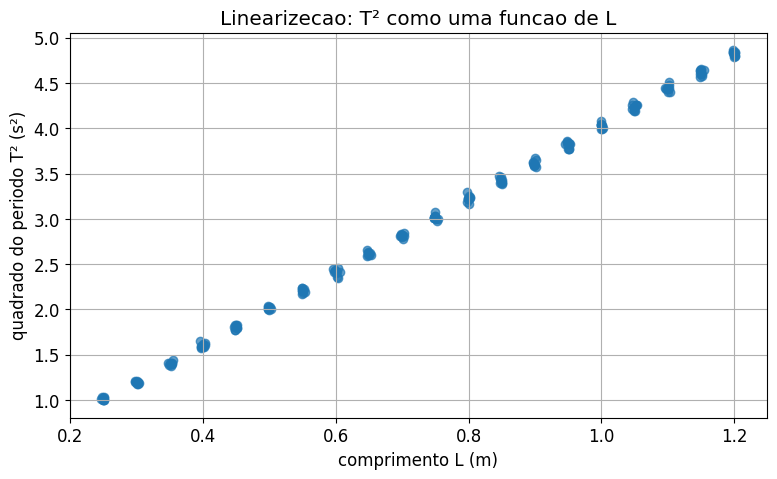

In [9]:
plt.figure()

plt.scatter(df['comprimento_m'], df['periodo_ao_quadrado_s2'], alpha=0.7)

plt.xlabel('comprimento L (m)')
plt.ylabel('quadrado do periodo T² (s²)')
plt.title('Linearizecao: T² como uma funcao de L')
plt.grid(True)

plt.show()

## 7. Média, desvio padrão e erro padrão

Em experimentos reais, repetimos medidas para reduzir o efeito de flutuações aleatórias.

Para cada comprimento, vamos calcular:

- média do comprimento;
- média do período;
- média de \(T^2\);
- desvio padrão de \(T^2\);
- número de repetições;
- erro padrão da média.

O **desvio padrão** indica a dispersão das medidas.

O **erro padrão da média** indica a incerteza associada à média:

$$
SE = \frac{s}{\sqrt{N}}
$$

onde:

- \(s\) é o desvio padrão;
- \(N\) é o número de repetições.

In [10]:
# Agrupamento dos dados por grupo de comprimento.
grouped = df.groupby('grupo_comprimento').agg(
    comprimento_medio_m=('comprimento_m', 'mean'),
    periodo_medio_s=('periodo_s', 'mean'),
    T2_medio_s2=('periodo_ao_quadrado_s2', 'mean'),
    T2_desvio_padrao_s2=('periodo_ao_quadrado_s2', 'std'),
    numero_medidas=('periodo_ao_quadrado_s2', 'count'),
    g_medio_m_s2=('g_estimado_m_s2', 'mean'),
    g_desvio_padrao_m_s2=('g_estimado_m_s2', 'std')
).reset_index()

# Agrupamento dos dados por grupo de comprimento..
grouped['T2_erro_padrao_s2'] = grouped['T2_desvio_padrao_s2'] / np.sqrt(grouped['numero_medidas'])
grouped['g_erro_padrao_m_s2'] = grouped['g_desvio_padrao_m_s2'] / np.sqrt(grouped['numero_medidas'])

grouped.head()

,grupo_comprimento,comprimento_medio_m,periodo_medio_s,T2_medio_s2,T2_desvio_padrao_s2,numero_medidas,g_medio_m_s2,g_desvio_padrao_m_s2,T2_erro_padrao_s2,g_erro_padrao_m_s2
0,1,0.24948,1.00754,1.015178,0.013701,10,9.70397,0.148411,0.004332,0.046932
1,2,0.30037,1.09278,1.194205,0.013921,10,9.93100,0.168868,0.004402,0.053401
2,3,0.35111,1.18489,1.404021,0.018773,10,9.87396,0.128638,0.005937,0.040679
3,4,0.39945,1.26626,1.603499,0.024612,10,9.83653,0.153836,0.007783,0.048647
4,5,0.44908,1.34367,1.805499,0.019912,10,9.82032,0.109120,0.006297,0.034507


## 8. Gráfico com barras de erro

Agora vamos representar \(T^2\) em função de \(L\), incluindo barras de erro.

As barras de erro ajudam a visualizar a incerteza experimental associada a cada ponto médio.

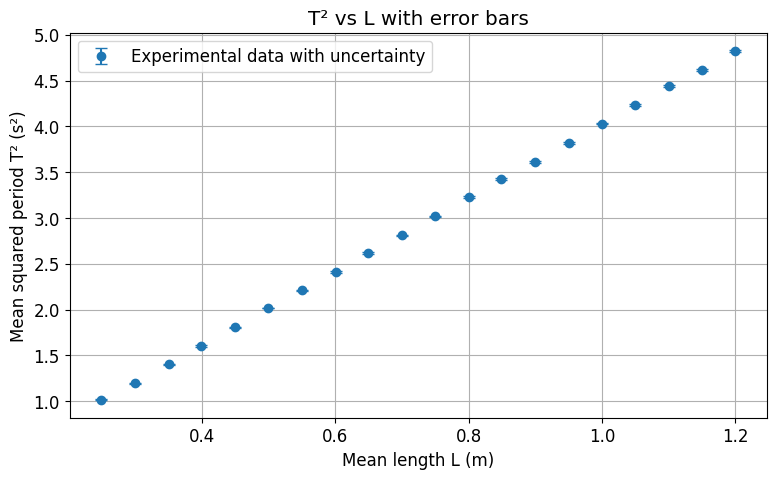

In [11]:
plt.figure()

plt.errorbar(
    grouped['comprimento_medio_m'],
    grouped['T2_medio_s2'],
    yerr=grouped['T2_erro_padrao_s2'],
    fmt='o',
    capsize=4,
    label='Experimental data with uncertainty'
)

plt.xlabel('Mean length L (m)')
plt.ylabel('Mean squared period T² (s²)')
plt.title('T² vs L with error bars')
plt.grid(True)
plt.legend()

plt.show()

## 9. Ajuste linear

Vamos ajustar uma reta aos dados médios:

$$
T^2 = aL + b
$$

onde:

- \(a\) é o coeficiente angular;
- \(b\) é o coeficiente linear.

Para um pêndulo ideal, \(b\) deveria ser próximo de zero.

In [12]:
# Regressão linear usando o SciPy.
slope, intercept, r_value, p_value, std_err = stats.linregress(
    grouped['comprimento_medio_m'],
    grouped['T2_medio_s2']
)

print('Linear fit results')
print(f'Slope a = {slope:.5f} s²/m')
print(f'Intercept b = {intercept:.5f} s²')
print(f'R² = {r_value**2:.5f}')
print(f'Standard error of the slope = {std_err:.5f} s²/m')

Linear fit results
Slope a = 4.02960 s²/m
Intercept b = -0.00340 s²
R² = 0.99995
Standard error of the slope = 0.00663 s²/m


## 10. Estimando a aceleração da gravidade

A partir do coeficiente angular:

$$
a = \frac{4\pi^2}{g}
$$

Logo:

$$
g = \frac{4\pi^2}{a}
$$

In [13]:
# Estimativa da aceleração gravitacional a partir da inclinação.
g_fit = 4 * np.pi**2 / slope

print(f'Estimated gravitational acceleration: g = {g_fit:.4f} m/s²')

Estimated gravitational acceleration: g = 9.7971 m/s²


## 11. Propagação de incerteza no valor de \(g\)

Como \(g\) depende do coeficiente angular \(a\):

$$
g = \frac{4\pi^2}{a}
$$

A incerteza de \(g\) pode ser estimada por propagação de incerteza:

$$
\Delta g = g \frac{\Delta a}{a}
$$

onde:

- \(\Delta a\) é a incerteza do coeficiente angular;
- \(a\) é o coeficiente angular.

In [15]:
# Propagação da incerteza da inclinação para g.
delta_g = g_fit * (std_err / slope)

print(f'g = ({g_fit:.4f} ± {delta_g:.4f}) m/s²')

g = (9.7971 ± 0.0161) m/s²


## 12. Gráfico final com reta ajustada

Agora vamos mostrar os pontos experimentais com barras de erro e a reta obtida pelo ajuste.

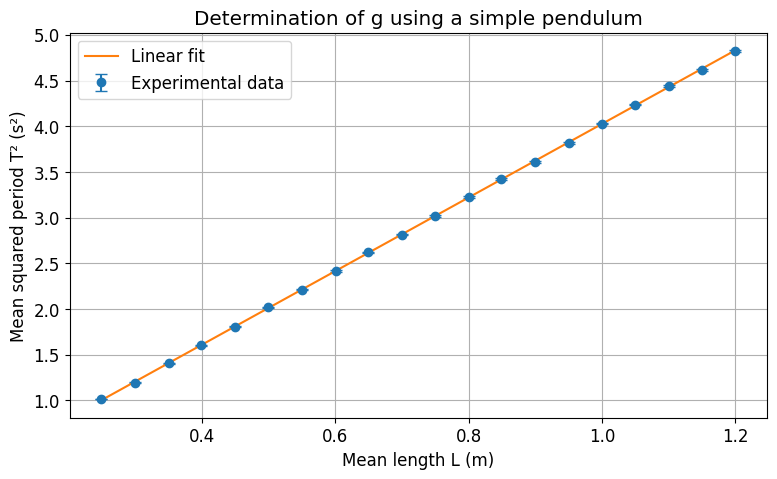

In [16]:
# Criando valores de x para a linha ajustada.
x_fit = np.linspace(grouped['comprimento_medio_m'].min(), grouped['comprimento_medio_m'].max(), 200)
y_fit = slope * x_fit + intercept

plt.figure()

plt.errorbar(
    grouped['comprimento_medio_m'],
    grouped['T2_medio_s2'],
    yerr=grouped['T2_erro_padrao_s2'],
    fmt='o',
    capsize=4,
    label='Experimental data'
)

plt.plot(x_fit, y_fit, label='Linear fit')

plt.xlabel('Mean length L (m)')
plt.ylabel('Mean squared period T² (s²)')
plt.title('Determination of g using a simple pendulum')
plt.grid(True)
plt.legend()

plt.show()

## 13. Erro absoluto e erro relativo

Vamos comparar o valor encontrado com o valor de referência:

$$
g_{ref} = 9.81 \, m/s^2
$$

O erro absoluto é:

$$
E_a = |g_{exp} - g_{ref}|
$$

O erro relativo percentual é:

$$
E_r = \frac{|g_{exp} - g_{ref}|}{g_{ref}} \times 100
$$

In [17]:
# Valor de referência para a aceleração gravitacional.
g_ref = 9.81

# Erros absolutos e relativos.
erro_absoluto = abs(g_fit - g_ref)
erro_relativo_percentual = (erro_absoluto / g_ref) * 100

print(f'Reference value: g_ref = {g_ref:.2f} m/s²')
print(f'Experimental value: g_exp = {g_fit:.4f} m/s²')
print(f'Absolute error = {erro_absoluto:.4f} m/s²')
print(f'Relative error = {erro_relativo_percentual:.2f}%')

Reference value: g_ref = 9.81 m/s²
Experimental value: g_exp = 9.7971 m/s²
Absolute error = 0.0129 m/s²
Relative error = 0.13%


## 14. Analisando os valores individuais de \(g\)

Cada medição individual também gera uma estimativa de \(g\).

Vamos visualizar a distribuição desses valores.

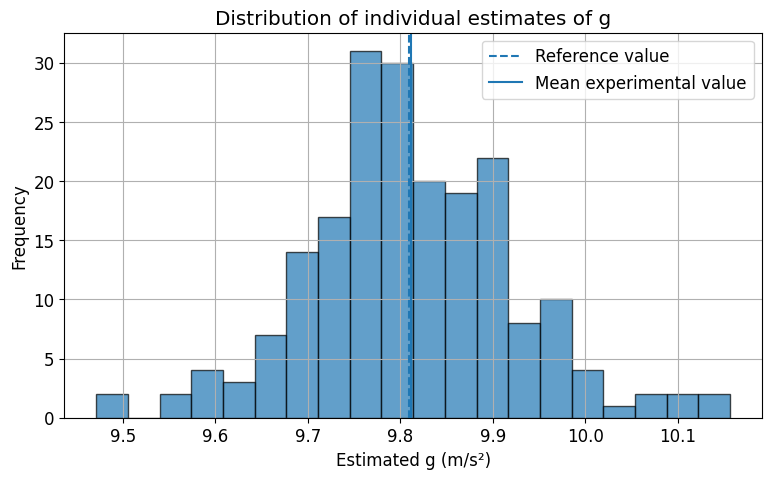

In [18]:
plt.figure()

plt.hist(df['g_estimado_m_s2'], bins=20, edgecolor='black', alpha=0.7)

plt.axvline(g_ref, linestyle='--', label='Reference value')
plt.axvline(df['g_estimado_m_s2'].mean(), linestyle='-', label='Mean experimental value')

plt.xlabel('Estimated g (m/s²)')
plt.ylabel('Frequency')
plt.title('Distribution of individual estimates of g')
plt.grid(True)
plt.legend()

plt.show()

## 15. Identificando possíveis outliers

Um outlier é um ponto que se afasta muito do comportamento esperado.

Uma forma simples de identificar possíveis outliers é usar o critério de 2 desvios padrão:

$$
|x - \bar{x}| > 2s
$$

Esse critério não deve ser usado automaticamente para excluir dados, mas ajuda a investigar medições suspeitas.

In [19]:
# Média e desvio padrão das estimativas individuais de g.
g_mean = df['g_estimado_m_s2'].mean()
g_std = df['g_estimado_m_s2'].std()

# Criação de limites com base em dois desvios padrão.
lower_limit = g_mean - 2 * g_std
upper_limit = g_mean + 2 * g_std

# Identificação de possíveis valores discrepantes..
df['possivel_outlier'] = (df['g_estimado_m_s2'] < lower_limit) | (df['g_estimado_m_s2'] > upper_limit)

# Exibindo possíveis valores discrepantes.
outliers = df[df['possivel_outlier']]
outliers.head()

,medicao,grupo_comprimento,repeticao,comprimento_m,tempo_10_oscilacoes_s,periodo_s,g_estimado_m_s2,incerteza_comprimento_m,incerteza_tempo_s,periodo_ao_quadrado_s2,possivel_outlier
3,4,1,4,0.2501,10.168,1.0168,9.5498,0.002,0.01,1.033882,True
6,7,1,7,0.2479,10.164,1.0164,9.4713,0.002,0.01,1.033069,True
13,14,2,4,0.3026,10.844,1.0844,10.1567,0.002,0.01,1.175923,True
14,15,2,5,0.3007,10.845,1.0845,10.0922,0.002,0.01,1.176140,True
16,17,2,7,0.3031,10.895,1.0895,10.0807,0.002,0.01,1.187010,True


In [20]:
print(f'Mean g = {g_mean:.4f} m/s²')
print(f'Standard deviation = {g_std:.4f} m/s²')
print(f'Lower limit = {lower_limit:.4f} m/s²')
print(f'Upper limit = {upper_limit:.4f} m/s²')
print(f'Number of possible outliers = {len(outliers)}')

Mean g = 9.8122 m/s²
Standard deviation = 0.1118 m/s²
Lower limit = 9.5886 m/s²
Upper limit = 10.0357 m/s²
Number of possible outliers = 10


## 16. Gráfico destacando os possíveis outliers

Vamos mostrar os pontos normais e os possíveis outliers em um mesmo gráfico.

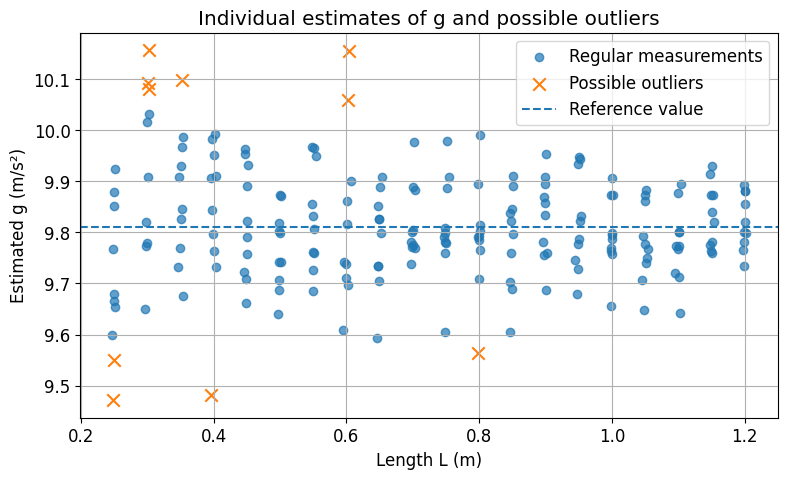

In [21]:
plt.figure()

normal_data = df[df['possivel_outlier'] == False]
outlier_data = df[df['possivel_outlier'] == True]

plt.scatter(
    normal_data['comprimento_m'],
    normal_data['g_estimado_m_s2'],
    alpha=0.7,
    label='Regular measurements'
)

plt.scatter(
    outlier_data['comprimento_m'],
    outlier_data['g_estimado_m_s2'],
    marker='x',
    s=80,
    label='Possible outliers'
)

plt.axhline(g_ref, linestyle='--', label='Reference value')

plt.xlabel('Length L (m)')
plt.ylabel('Estimated g (m/s²)')
plt.title('Individual estimates of g and possible outliers')
plt.grid(True)
plt.legend()

plt.show()

## 17. Resultado final do experimento

Uma forma adequada de apresentar o resultado é:

$$
g = (g_{exp} \pm \Delta g) \, m/s^2
$$

Também é importante informar o erro relativo percentual em relação ao valor de referência.

In [22]:
print('Final experimental result')
print(f'g = ({g_fit:.4f} ± {delta_g:.4f}) m/s²')
print(f'Relative error = {erro_relativo_percentual:.2f}%')
print(f'R² of the linear fit = {r_value**2:.5f}')

Final experimental result
g = (9.7971 ± 0.0161) m/s²
Relative error = 0.13%
R² of the linear fit = 0.99995


## 18. Salvando uma tabela processada

Agora vamos salvar uma nova tabela com os dados agrupados e os principais resultados estatísticos.

Esse passo mostra aos alunos como gerar novos arquivos após a análise.

In [23]:
# Caminho de saída para a tabela processada.
output_path = '/content/drive/MyDrive/Colab Notebooks/dados_processados_erro_incerteza_pendulo.csv'

# Salvar os resultados agrupados como um novo arquivo CSV.
grouped.to_csv(output_path, index=False)

print(f'Processed file saved at: {output_path}')

Processed file saved at: /content/drive/MyDrive/Colab Notebooks/dados_processados_erro_incerteza_pendulo.csv


# Conclusão da aula

Nesta aula, aprendemos que uma análise experimental em Física envolve mais do que calcular uma fórmula.

O processo completo inclui:

1. carregar dados experimentais;
2. visualizar os dados;
3. calcular médias e desvios;
4. representar incertezas com barras de erro;
5. fazer ajuste linear;
6. estimar uma grandeza física;
7. calcular erro absoluto e erro relativo;
8. identificar possíveis outliers;
9. apresentar o resultado final com incerteza.

Esse tipo de análise aproxima os alunos da prática real de laboratório e pesquisa científica.